# Lab 3: Decision trees

Mark missing zeros -> split -> train medians -> fit -> metrics.
Part A predicts Outcome. Part B predicts Glucose and keeps Outcome as a predictor,
as in the lab. Trees do not need scaling.

The lab calls sklearn's entropy tree "ID3". It is an ID3-style comparison:
sklearn uses binary CART trees even with entropy, not the original ID3 algorithm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

RS = 1370
TARGET = "Outcome"
ZERO_AS_MISSING = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]


## 1. Load & inspect

In [2]:
raw = pd.read_csv("pima_indians_diabetes.csv")
print("Rows:", raw.shape[0], "Cols:", raw.shape[1])
print("Duplicates:", raw.duplicated().sum())
raw.head()


Rows: 768 Cols: 9
Duplicates: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Clean — treat 0 as hidden-missing in the medical columns

In [3]:
clean = raw.copy()
clean[ZERO_AS_MISSING] = clean[ZERO_AS_MISSING].replace(0, np.nan)
print("Missing % after marking zeros:")
print((clean[ZERO_AS_MISSING].isna().mean()*100).round(2))


Missing % after marking zeros:
Glucose           0.65
BloodPressure     4.56
SkinThickness    29.56
Insulin          48.70
BMI               1.43
dtype: float64


## 3. Class balance + correlation

Outcome
0    500
1    268
Name: count, dtype: int64


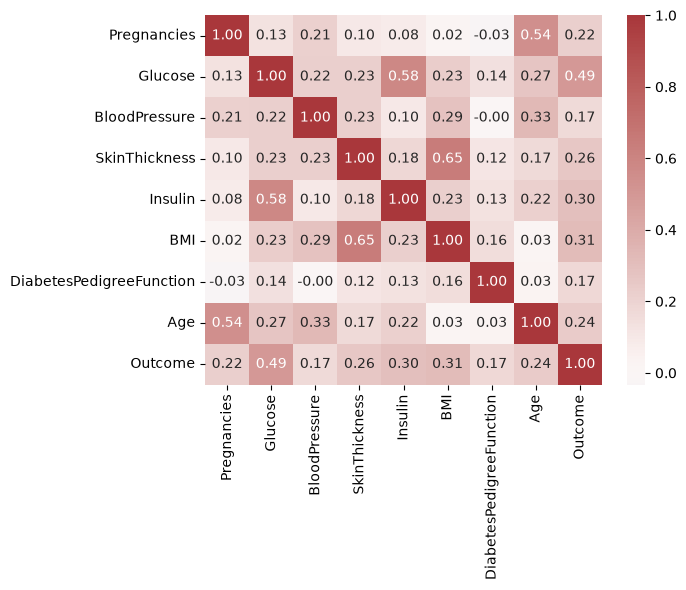

In [4]:
print(clean[TARGET].value_counts())
sns.heatmap(clean.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.show()


## 4. Split FIRST, then impute with TRAIN medians (no leakage)

In [5]:
X = clean.drop(columns=[TARGET])
y = clean[TARGET]
FEATURES = list(X.columns)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RS, stratify=y)
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test  = X_test.fillna(train_medians)
print("Train:", len(X_train), "Test:", len(X_test), "| positive rate:", round(y_train.mean(),3))


Train: 537 Test: 231 | positive rate: 0.348


## 5. Entropy, Gini, information gain and gain ratio

This reproduces the lab's search over nine percentile thresholds. The reported
Gini gain and gain ratio belong to the threshold with highest information gain.
The fitted sklearn tree searches its own thresholds.

In [6]:
def entropy(labels):
    p = labels.value_counts(normalize=True)
    return float(-(p*np.log2(p)).sum())
def gini(labels):
    p = labels.value_counts(normalize=True)
    return float(1 - (p**2).sum())

def best_split(feature, labels):
    pe, pg = entropy(labels), gini(labels)
    best = {"IG":0,"GiniGain":0,"GainRatio":0,"Thr":None}
    for thr in np.percentile(feature, range(10,100,10)):
        L, R = labels[feature<=thr], labels[feature>thr]
        if len(L)==0 or len(R)==0: continue
        wL = len(L)/len(labels)
        wR = 1-wL
        ig = pe - (wL*entropy(L)+wR*entropy(R))
        split_info = -(wL*np.log2(wL) + wR*np.log2(wR))
        if ig > best["IG"]:
            best = {"IG":ig, "GainRatio":ig/split_info, "GiniGain":pg-(wL*gini(L)+wR*gini(R)), "Thr":thr}
    return best

print("Training entropy:", round(entropy(y_train),4), "| gini:", round(gini(y_train),4))
crit = pd.DataFrame([dict(Attribute=n, **best_split(X_train[n], y_train)) for n in FEATURES])
print(crit.sort_values("IG", ascending=False).round(4).to_string(index=False))


Training entropy: 0.9325 | gini: 0.4539
               Attribute     IG  GainRatio  GiniGain     Thr
                 Glucose 0.1178     0.1214    0.0737 124.000
                     Age 0.0726     0.0741    0.0434  27.000
                     BMI 0.0618     0.0853    0.0329  26.720
                 Insulin 0.0378     0.0507    0.0214 105.000
           SkinThickness 0.0325     0.0440    0.0185  23.000
             Pregnancies 0.0282     0.0328    0.0182   5.000
DiabetesPedigreeFunction 0.0210     0.0291    0.0137   0.692
           BloodPressure 0.0159     0.0165    0.0101  74.000


## 6. ID3 (entropy) and CART (gini) trees

ID3: train=0.7765 test=0.7706 root=Glucose depth=4 leaves=13
CART: train=0.7765 test=0.7706 root=Glucose depth=4 leaves=14


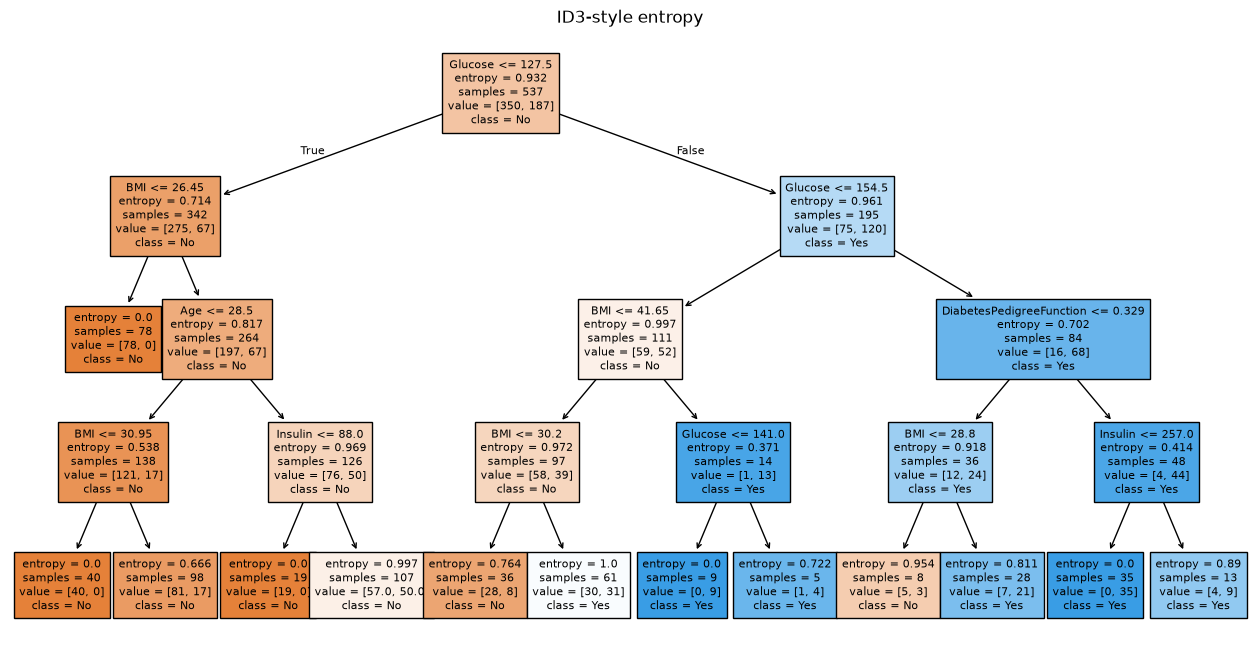

|--- Glucose <= 127.50
|   |--- BMI <= 26.45
|   |   |--- class: 0
|   |--- BMI >  26.45
|   |   |--- Age <= 28.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Age >  28.50
|   |   |   |--- truncated branch of depth 2
|--- Glucose >  127.50
|   |--- Glucose <= 154.50
|   |   |--- BMI <= 41.65
|   |   |   |--- truncated branch of depth 2
|   |   |--- BMI >  41.65
|   |   |   |--- truncated branch of depth 2
|   |--- Glucose >  154.50
|   |   |--- DiabetesPedigreeFunction <= 0.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- DiabetesPedigreeFunction >  0.33
|   |   |   |--- truncated branch of depth 2



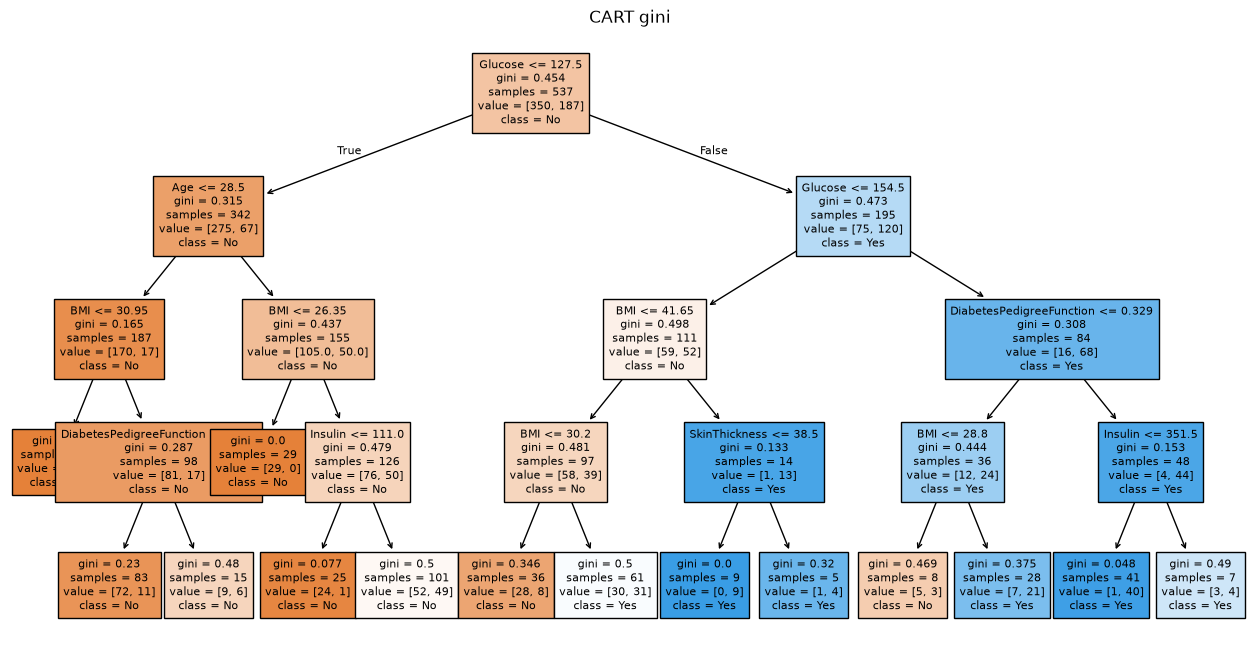

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 30.95
|   |   |   |--- class: 0
|   |   |--- BMI >  30.95
|   |   |   |--- truncated branch of depth 2
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- truncated branch of depth 2
|--- Glucose >  127.50
|   |--- Glucose <= 154.50
|   |   |--- BMI <= 41.65
|   |   |   |--- truncated branch of depth 2
|   |   |--- BMI >  41.65
|   |   |   |--- truncated branch of depth 2
|   |--- Glucose >  154.50
|   |   |--- DiabetesPedigreeFunction <= 0.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- DiabetesPedigreeFunction >  0.33
|   |   |   |--- truncated branch of depth 2



In [7]:
id3  = DecisionTreeClassifier(criterion="entropy", max_depth=4, min_samples_leaf=5, random_state=RS).fit(X_train,y_train)
cart = DecisionTreeClassifier(criterion="gini",    max_depth=4, min_samples_leaf=5, random_state=RS).fit(X_train,y_train)
for name,m in [("ID3",id3),("CART",cart)]:
    print(f"{name}: train={m.score(X_train,y_train):.4f} test={m.score(X_test,y_test):.4f} "
          f"root={FEATURES[m.tree_.feature[0]]} depth={m.get_depth()} leaves={m.get_n_leaves()}")
for name, model in [("ID3-style entropy", id3), ("CART gini", cart)]:
    plt.figure(figsize=(16, 8))
    plot_tree(model, feature_names=FEATURES, class_names=["No", "Yes"], filled=True, fontsize=8)
    plt.title(name)
    plt.show()
    print(export_text(model, feature_names=FEATURES, max_depth=2))


## 7. Metrics + confusion matrix (test set)

ID3
Train               precision    recall  f1-score   support

           0     0.7979    0.8800    0.8370       350
           1     0.7219    0.5829    0.6450       187

    accuracy                         0.7765       537
   macro avg     0.7599    0.7314    0.7410       537
weighted avg     0.7714    0.7765    0.7701       537

Test               precision    recall  f1-score   support

           0     0.7939    0.8733    0.8317       150
           1     0.7121    0.5802    0.6395        81

    accuracy                         0.7706       231
   macro avg     0.7530    0.7268    0.7356       231
weighted avg     0.7652    0.7706    0.7643       231



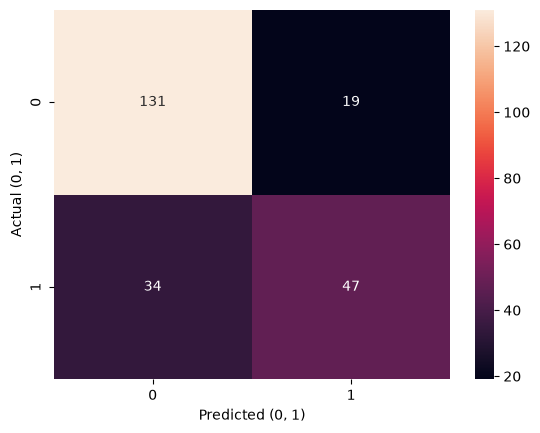

CART
Train               precision    recall  f1-score   support

           0     0.7979    0.8800    0.8370       350
           1     0.7219    0.5829    0.6450       187

    accuracy                         0.7765       537
   macro avg     0.7599    0.7314    0.7410       537
weighted avg     0.7714    0.7765    0.7701       537

Test               precision    recall  f1-score   support

           0     0.7939    0.8733    0.8317       150
           1     0.7121    0.5802    0.6395        81

    accuracy                         0.7706       231
   macro avg     0.7530    0.7268    0.7356       231
weighted avg     0.7652    0.7706    0.7643       231



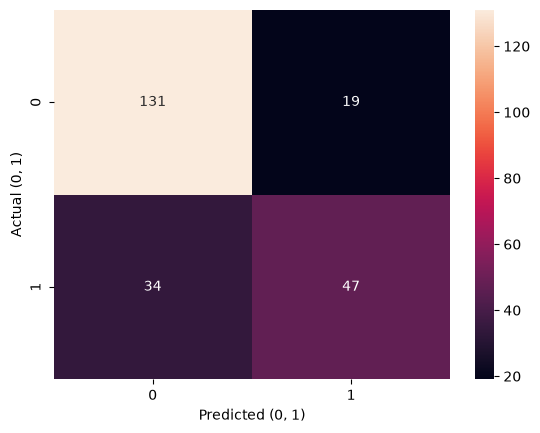

In [8]:
for name, model in [("ID3", id3), ("CART", cart)]:
    print(name)
    for part, A, actual in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        pred = model.predict(A)
        print(part, classification_report(actual, pred, digits=4, zero_division=0))
    sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True, fmt="d")
    plt.xlabel("Predicted (0, 1)")
    plt.ylabel("Actual (0, 1)")
    plt.show()


## 8. Feature importance

In [9]:
imp = pd.DataFrame({"ID3":id3.feature_importances_, "CART":cart.feature_importances_}, index=FEATURES)
print(imp.round(3).sort_values("CART", ascending=False))


                            ID3   CART
Glucose                   0.455  0.543
BMI                       0.293  0.223
Insulin                   0.122  0.098
Age                       0.099  0.090
DiabetesPedigreeFunction  0.031  0.043
SkinThickness             0.000  0.003
BloodPressure             0.000  0.000
Pregnancies               0.000  0.000


## Part B — Regression tree (predict Glucose)

In [10]:
REG_TARGET = "Glucose"
rd = clean.dropna(subset=[REG_TARGET]).copy()
Xr = rd.drop(columns=[REG_TARGET])
yr = rd[REG_TARGET]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.30, random_state=RS)
rmed = Xr_tr.median()
Xr_tr = Xr_tr.fillna(rmed)
Xr_te = Xr_te.fillna(rmed)

reg = DecisionTreeRegressor(criterion="squared_error", max_depth=4, min_samples_leaf=10, random_state=RS).fit(Xr_tr, yr_tr)
pred = reg.predict(Xr_te)
print(f"MAE={mean_absolute_error(yr_te,pred):.3f} RMSE={np.sqrt(mean_squared_error(yr_te,pred)):.3f} R2={r2_score(yr_te,pred):.3f}")
baseline = np.full(len(yr_te), yr_tr.mean())
print("Baseline RMSE (predict mean):", round(np.sqrt(mean_squared_error(yr_te, baseline)),3))


MAE=21.024 RMSE=26.616 R2=0.287
Baseline RMSE (predict mean): 31.707


## Part B — Effect of depth (over/underfitting)

In [11]:
for d in [2,4,6,8,10]:
    m = DecisionTreeRegressor(criterion="squared_error", max_depth=d, random_state=RS).fit(Xr_tr,yr_tr)
    tr = r2_score(yr_tr, m.predict(Xr_tr))
    te = r2_score(yr_te, m.predict(Xr_te))
    print(f"depth={d:2d}  train R2={tr:.3f}  test R2={te:.3f}  gap={tr-te:.3f}")


depth= 2  train R2=0.338  test R2=0.315  gap=0.023
depth= 4  train R2=0.478  test R2=0.314  gap=0.164
depth= 6  train R2=0.599  test R2=0.154  gap=0.445
depth= 8  train R2=0.702  test R2=0.163  gap=0.538
depth=10  train R2=0.808  test R2=0.024  gap=0.785


## Extra lab checks: pruning and regression plots

Run these if asked to compare full/pruned trees or explain the regression tree.

entropy Full depth/leaves: 16 88 train/test: 1.0 0.6883116883116883
entropy Pruned depth/leaves: 4 13 train/test: 0.776536312849162 0.7705627705627706
gini Full depth/leaves: 15 91 train/test: 1.0 0.7186147186147186
gini Pruned depth/leaves: 4 14 train/test: 0.776536312849162 0.7705627705627706


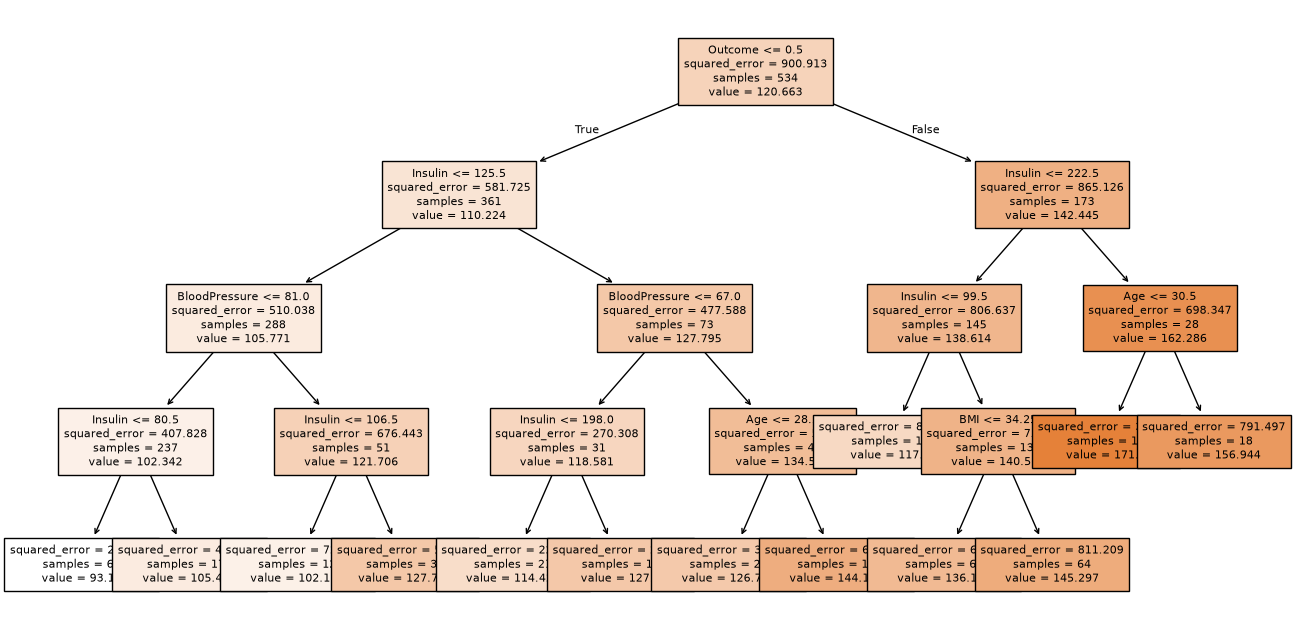

Outcome                     0.576862
Insulin                     0.291769
BloodPressure               0.096500
Age                         0.021740
BMI                         0.013129
Pregnancies                 0.000000
SkinThickness               0.000000
DiabetesPedigreeFunction    0.000000
dtype: float64
Train MAE/MSE/RMSE/R2: 17.553031227466576 506.7560492178134 22.511242729307803 0.43750808689814813
Test MAE/MSE/RMSE/R2: 21.024412642333132 708.397964284491 26.615746547570122 0.2871059404910521


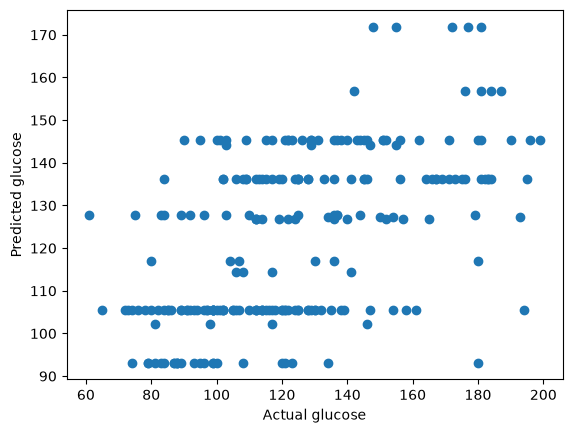

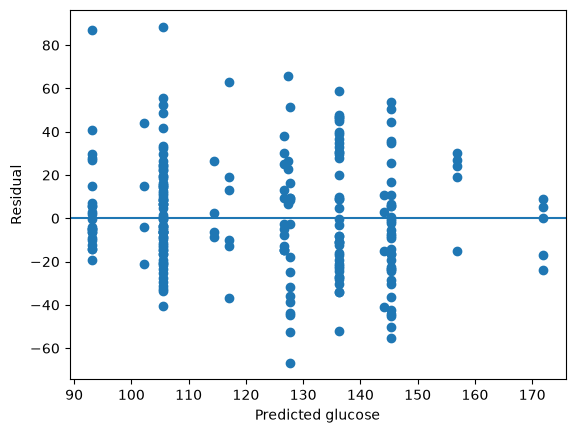

In [12]:
for criterion, pruned in [("entropy", id3), ("gini", cart)]:
    full = DecisionTreeClassifier(criterion=criterion, random_state=RS).fit(X_train, y_train)
    for name, model in [("Full", full), ("Pruned", pruned)]:
        print(criterion, name, "depth/leaves:", model.get_depth(), model.get_n_leaves(),
              "train/test:", model.score(X_train, y_train), model.score(X_test, y_test))

plt.figure(figsize=(16, 8))
plot_tree(reg, feature_names=list(Xr.columns), filled=True, fontsize=8)
plt.show()
print(pd.Series(reg.feature_importances_, index=Xr.columns).sort_values(ascending=False))
for part, A, actual in [("Train", Xr_tr, yr_tr), ("Test", Xr_te, yr_te)]:
    pred = reg.predict(A)
    mse = mean_squared_error(actual, pred)
    print(part, "MAE/MSE/RMSE/R2:", mean_absolute_error(actual, pred), mse,
          np.sqrt(mse), r2_score(actual, pred))
pred = reg.predict(Xr_te)
plt.scatter(yr_te, pred)
plt.xlabel("Actual glucose")
plt.ylabel("Predicted glucose")
plt.show()
plt.scatter(pred, yr_te - pred)
plt.axhline(0)
plt.xlabel("Predicted glucose")
plt.ylabel("Residual")
plt.show()
